# 2. Features


Module importing


In [29]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Library importing

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from src.data import load_cache
from src.splits import SPLITS
from src.config import FIGURES_DIR, EOL_AH, V_GRID
from src.features import build_feature_table

(cycle life issue fix)

In [31]:
# from collections import Counter
# import numpy as np
# from src.config import PROCESSED_DIR, RAW_DIR
# from src.data import cycle_life
# from src.splits import SPLITS

# # 1. Did the raw downloads arrive? Each file should be several GB.
# for p in sorted(RAW_DIR.glob("*.mat")):
#     print(p.name, f"{p.stat().st_size / 1e9:.1f} GB")

# # 2. Did preprocessing write files for every batch?
# print("processed:", Counter(p.stem.split("_")[1][:2] for p in PROCESSED_DIR.glob("*.pkl")))

# # 3. What's in the cache?
# print("cache:", Counter(cid[:2] for cid in cells))

# # 4. Missing from the cache, or present but with no end-of-life label?
# for name, ids in SPLITS.items():
#     missing = [c for c in ids if c not in cells]
#     no_eol = [c for c in ids if c in cells and np.isnan(cycle_life(cells[c]["qd"]))]
#     print(f"{name}: missing {len(missing)}, no EOL {len(no_eol)}", no_eol[:5])

# from src.data import clean_capacity

# for cid in ["b1c0", "b3c0", "b2c3"]:          # b2c3 works; it's the reference
#     qd = cells[cid]["qd"]
#     bad = ~np.isfinite(qd) | (qd < 0.55) | (qd > 1.32)
#     clean = clean_capacity(qd)
#     print(f"{cid}: {len(qd)} cycles (last cycle_number {cells[cid]['cycle_number'][-1]}) | "
#           f"raw min {np.nanmin(qd):.3f}, max {np.nanmax(qd):.3f} | "
#           f"NaN {np.isnan(qd).sum()} | flagged bad {bad.sum()} | cleaned min {np.nanmin(clean):.3f}")
#     print("   first 5:", np.round(qd[:5], 3), "| last 5:", np.round(qd[-5:], 3))

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# for ax, cid in zip(axes, ["b1c0", "b3c0", "b2c3"]):
#     ax.plot(cells[cid]["qd"], lw=0.6, label="raw")
#     ax.plot(clean_capacity(cells[cid]["qd"]), lw=0.8, label="cleaned")
#     ax.axhline(0.88, ls="--", c="red", lw=1)
#     ax.set(title=cid, xlabel="cycle index", ylabel="qd (Ah)")
#     ax.legend()

Feature table

In [32]:
cells = load_cache()
tables = {name: build_feature_table(cells, ids) for name, ids in SPLITS.items()}
print({k: len(v) for k, v in tables.items()})

train = tables["train"].assign(log_life=lambda d: np.log10(d["cycle_life"]))
corr = train.corr(method="spearman")["log_life"].drop(["log_life", "cycle_life"])
print(corr.sort_values())

train.drop(columns="log_life").describe().T

{'train': 41, 'primary_test': 42, 'secondary_test': 40}
dq_log_min            -0.712462
dq_log_mean           -0.704012
dq_log_var            -0.689637
ir_min_2_late         -0.535000
temp_max_2_late       -0.234961
temp_mean_2_late       0.078669
dq_log_kurt            0.085203
qd_max_minus_cycle2    0.087119
qd_slope_2_late        0.230692
dq_log_skew            0.332883
qd_intercept_2_late    0.409810
qd_cycle2              0.474452
qd_slope_last10        0.488478
ir_change              0.500414
charge_time_first5     0.558610
Name: log_life, dtype: float64


,count,mean,std,min,25%,50%,75%,max
dq_log_var,41.0,-3.676412,0.374930,-5.135183,-3.821806,-3.641683,-3.452192,-2.774435
dq_log_min,41.0,-1.355802,0.182425,-2.045149,-1.421391,-1.347632,-1.238743,-0.908475
dq_log_mean,41.0,-1.698267,0.211209,-2.428025,-1.765095,-1.678864,-1.568213,-1.156284
dq_log_skew,41.0,-0.926704,0.601135,-3.330688,-1.108179,-0.853264,-0.523291,-0.217875
dq_log_kurt,41.0,0.250280,0.025509,0.197813,0.235162,0.243090,0.259199,0.326912
qd_cycle2,41.0,1.075679,0.008340,1.048029,1.071910,1.076178,1.079789,1.095110
qd_max_minus_cycle2,41.0,0.004049,0.001847,0.001528,0.002655,0.003561,0.005417,0.008207
qd_slope_2_late,41.0,-0.000030,0.000075,-0.000361,-0.000034,-0.000010,0.000009,0.000032
qd_intercept_2_late,41.0,1.079092,0.008044,1.051230,1.076407,1.079126,1.083812,1.097406
qd_slope_last10,41.0,-0.000077,0.000096,-0.000541,-0.000083,-0.000043,-0.000029,-0.000007


Feature correlation

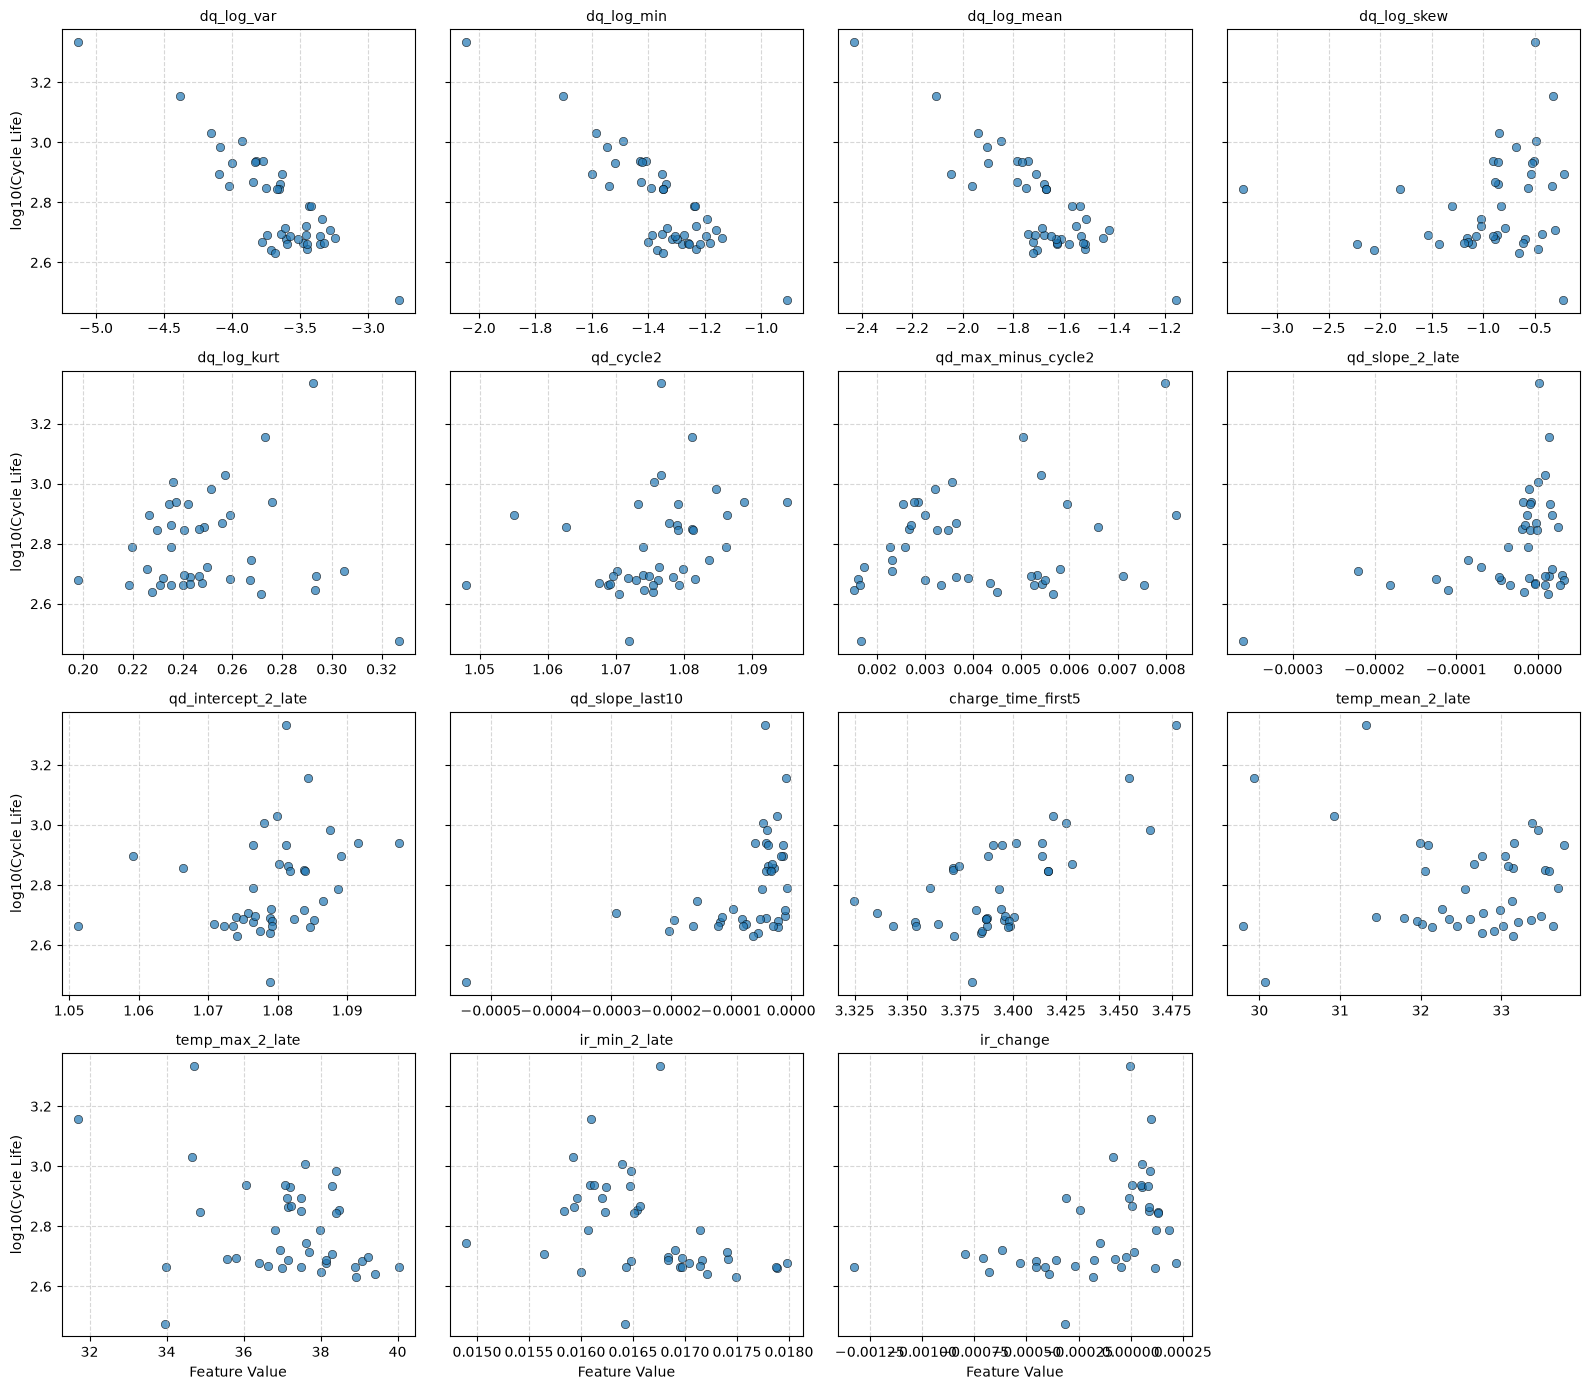

In [33]:
features = [col for col in train.columns if col not in ["log_life", "cycle_life"]]
n_features = len(features)

n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5), sharey=True)
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    ax.scatter(train[feat], train["log_life"], alpha=0.7, color="tab:blue", edgecolors="k", linewidths=0.5)
    ax.set_title(feat, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    
    if i >= n_cols * (n_rows - 1):
        ax.set_xlabel("Feature Value")
    if i % n_cols == 0:
        ax.set_ylabel("log10(Cycle Life)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.savefig(FIGURES_DIR / "feature_vs_loglife_grid.png", dpi=150, bbox_inches="tight")
plt.show()